<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/castro_taborda_5Junio/Evaluacion/castro_taborda_evaluacion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: Castro, Maria
- Apellido2, Nombre2: Taborda, Alejandro

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [1]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1000416767
cedula2 = 1000901151

In [2]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 918
Parámetros — alpha: 1.30, beta: 2.20, gamma: 0.200, ruido: 0.130
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

*a: El hecho de que el spline interpole Z_data implica que va a trabajar con datos que tienen ruido, esto forzará la función a que pase por los datos que tienen ruido y no los originales, esto ocasionando que la funcion no sea suave (fenomeno runge)  
b: Justamente en este caso es preferible usar minimos cuadrados debido a que con Z_data presentamos ruido*

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

*a: Como hay una malla de 15x15, es decir, 225 puntos; así, la matriz A tendrá 225 filas y 3 columnas construidas de la siguiente manera:*

*Primera columna: Vector columna lleno de unos.*

*Segunda columna: Vector columna que contiene las coordenadas de x de los 225 puntos.*

*Tercera columna: Vector columna que contiene las coordenadas de y de los 225 puntos.*


*b: Representa la tendencia lineal global de los datos. Es útil porque revela la inclinación promedio.*

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

** *texto en cursiva*Respuesta P1.3:**

*a: El objetivo del PCA es encontrar las direcciones donde los datos están más esparcidos (es decir, la máxima varianza), Si no se centran los datos el algoritmo va a interpretar que la distancia desde el origen hasta el centro de la nube de puntos como la varianza.*

*b: Es un vector tridimensional que define la línea recta a lo largo de la cual la superficie es más larga o tiene mayor extensión.*

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [5]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina
# 1
spline_bicubico = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# 2. Creación de la malla fina (100x100 puntos)
n_fina = 100
x_fina = np.linspace(-3, 3, n_fina)
y_fina = np.linspace(-3, 3, n_fina)

# Creamos las matrices 2D para la malla fina
X_fina, Y_fina = np.meshgrid(x_fina, y_fina, indexing='ij')

# 3. Evaluación del Spline en la malla fina
Z_spline = spline_bicubico(x_fina, y_fina)


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

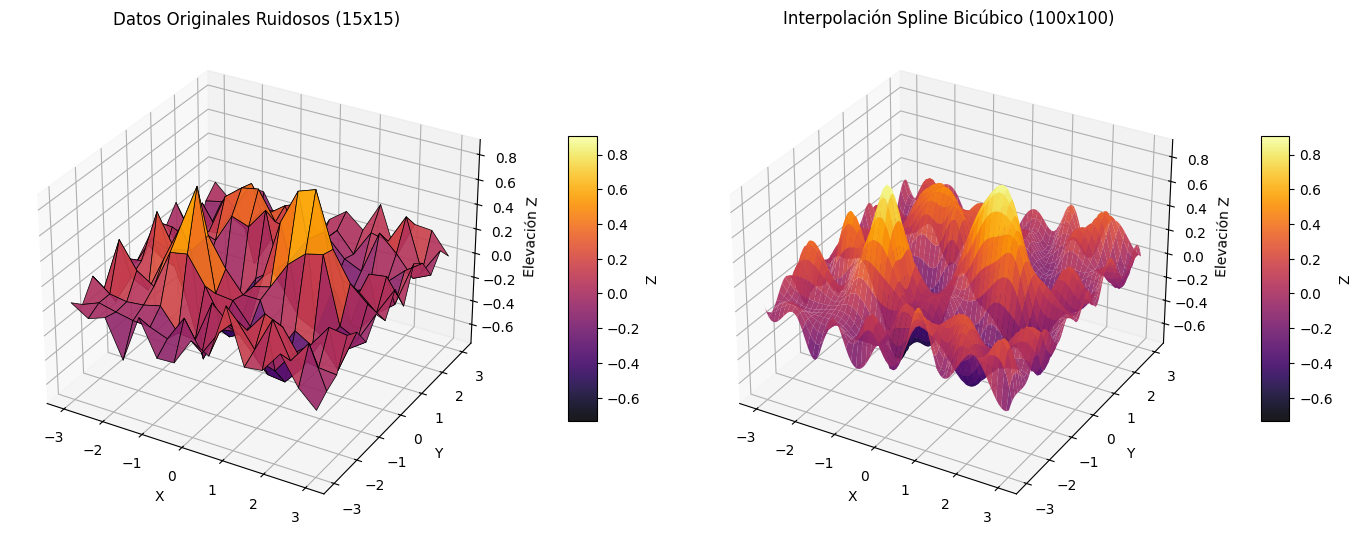

In [9]:
# 1. Definir límites de color globales (vmin, vmax)
# Calculamos el mínimo y máximo absoluto entre ambas superficies para unificar la escala
color_min = min(Z_data.min(), Z_spline.min())
color_max = max(Z_data.max(), Z_spline.max())
mapa_color = 'inferno'

# 2. Crear la figura y los subplots indicando que son en 3D
fig = plt.figure(figsize=(14, 6))

# --- PANEL IZQUIERDO: Datos Originales (Z_data) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# Graficamos la superficie. Le ponemos edgecolor para ver la cuadrícula de 15x15
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap=mapa_color,
                         vmin=color_min, vmax=color_max,
                         edgecolor='black', linewidth=0.5, alpha=0.9)

ax1.set_title('Datos Originales Ruidosos (15x15)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Elevación Z')
# Colorbar exclusivo para el panel izquierdo
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1, label='Z')

# --- PANEL DERECHO: Interpolación Spline (Z_spline) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# Graficamos la superficie fina.
surf2 = ax2.plot_surface(X_fina, Y_fina, Z_spline, cmap=mapa_color,
                         vmin=color_min, vmax=color_max,
                         edgecolor='none', alpha=0.9)

ax2.set_title('Interpolación Spline Bicúbico (100x100)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Elevación Z')
# Colorbar exclusivo para el panel derecho
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1, label='Z')

# Ajustamos el layout para que no se superpongan
plt.tight_layout()
plt.show()

## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [10]:
# 1. Aplanar las matrices de la malla (de 15x15 a vectores 1D de 225 elementos)
x_flat = X_raw.flatten()
y_flat = Y_raw.flatten()
z_flat = Z_data.flatten()

# 2. Construir la matriz de diseño A (Tamaño: 225 filas x 3 columnas)
# Columna 1: Unos (asociada a c0)
# Columna 2: Coordenadas x (asociada a c1)
# Columna 3: Coordenadas y (asociada a c2)
col_unos = np.ones_like(x_flat)
A = np.column_stack([col_unos, x_flat, y_flat])

# 3. Resolver el sistema sobre-determinado Ac = z usando np.linalg.lstsq
c, residuos, rank, s = np.linalg.lstsq(A, z_flat, rcond=None)

# Extraer los coeficientes individuales
c0, c1, c2 = c

# 4. Imprimir los resultados exigidos con 4 decimales
print("Coeficientes del plano ajustado (Mínimos Cuadrados):")
print(f"c0 (altura base)    = {c0:.4f}")
print(f"c1 (pendiente en X) = {c1:.4f}")
print(f"c2 (pendiente en Y) = {c2:.4f}")

Coeficientes del plano ajustado (Mínimos Cuadrados):
c0 (altura base)    = 0.0160
c1 (pendiente en X) = -0.0045
c2 (pendiente en Y) = 0.0001


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

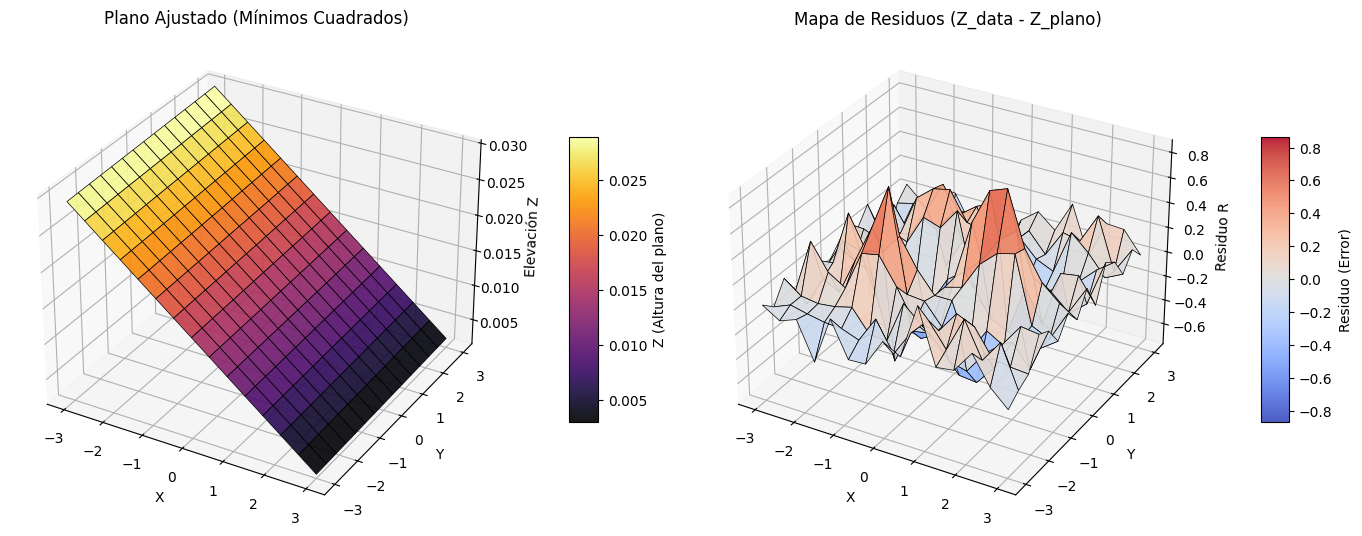

In [12]:
# 1. Evaluar el plano ajustado en la malla gruesa (15x15)
# Usamos los coeficientes c0, c1, c2 y las matrices X_raw y Y_raw
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# 2. Calcular el mapa de residuos R
R = Z_data - Z_plano

# 3. Preparar los límites para el colormap divergente
limite_R = np.max(np.abs(R))

# 4. Crear la figura con dos paneles 3D
fig = plt.figure(figsize=(14, 6))

# --- PANEL IZQUIERDO: Plano Ajustado (Z_plano) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf_plano = ax1.plot_surface(X_raw, Y_raw, Z_plano, cmap='inferno',
                              edgecolor='black', linewidth=0.5, alpha=0.9)
ax1.set_title('Plano Ajustado (Mínimos Cuadrados)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Elevación Z')
fig.colorbar(surf_plano, ax=ax1, shrink=0.5, aspect=10, pad=0.1, label='Z (Altura del plano)')

# --- PANEL DERECHO: Mapa de Residuos R ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# Usamos 'coolwarm' que es un colormap divergente.
surf_R = ax2.plot_surface(X_raw, Y_raw, R, cmap='coolwarm',
                          vmin=-limite_R, vmax=limite_R,
                          edgecolor='black', linewidth=0.5, alpha=0.9)
ax2.set_title('Mapa de Residuos (Z_data - Z_plano)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Residuo R')
fig.colorbar(surf_R, ax=ax2, shrink=0.5, aspect=10, pad=0.1, label='Residuo (Error)')

# Ajustamos para evitar superposiciones
plt.tight_layout()
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [14]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=1.30, omega2=2.20


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

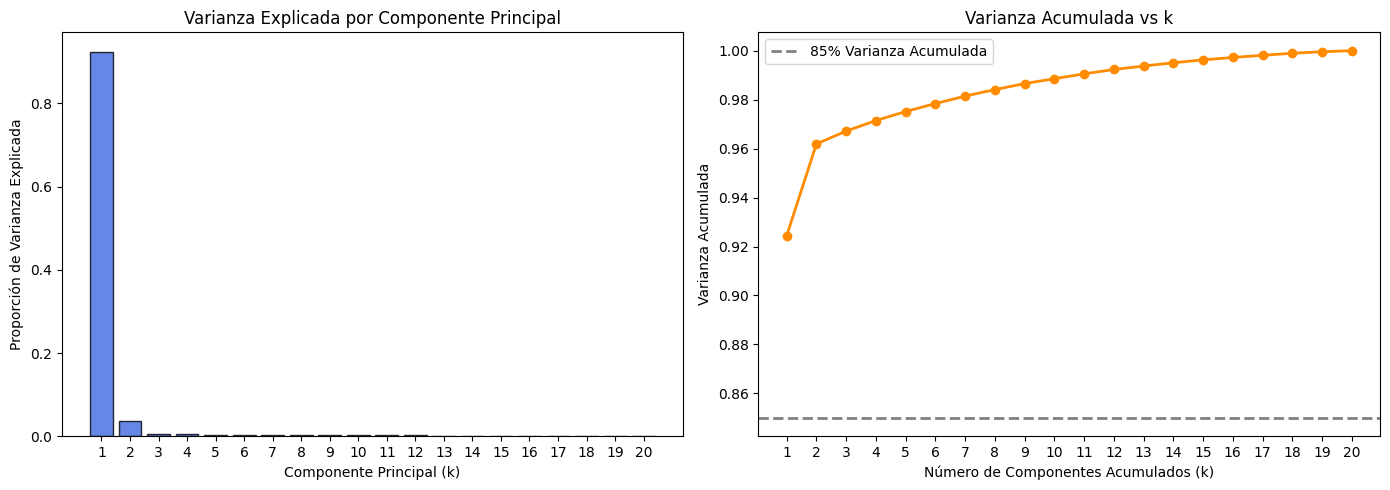

In [18]:
# Respuesta P4.1 - PCA Y SVD SOBRE SEÑALES SÍSMICAS
# 1. Centrar las filas de X
X_centrado = X - np.mean(X, axis=1, keepdims=True)

# 2. Calcular la SVD (Descomposición en Valores Singulares)
U, S, Vt = np.linalg.svd(X_centrado, full_matrices=False)

# 3. Calcular la varianza explicada y acumulada
varianza_explicada = (S ** 2) / np.sum(S ** 2)
varianza_acumulada = np.cumsum(varianza_explicada)

# 4. Crear la figura con dos paneles (1x2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- PANEL IZQUIERDO: Gráfico de Barras (Scree Plot) ---
k_componentes = np.arange(1, len(S) + 1) # Eje X: 1, 2, 3... 20
ax1.bar(k_componentes, varianza_explicada, color='royalblue', edgecolor='black', alpha=0.8)
ax1.set_title('Varianza Explicada por Componente Principal')
ax1.set_xlabel('Componente Principal (k)')
ax1.set_ylabel('Proporción de Varianza Explicada')
ax1.set_xticks(k_componentes) # Para mostrar todos los números del 1 al 20

# --- PANEL DERECHO: Varianza Acumulada ---
ax2.plot(k_componentes, varianza_acumulada, marker='o', linestyle='-', color='darkorange', linewidth=2)
# Línea punteada horizontal en el 85%
ax2.axhline(y=0.85, color='gray', linestyle='--', linewidth=2, label='85% Varianza Acumulada')

ax2.set_title('Varianza Acumulada vs k')
ax2.set_xlabel('Número de Componentes Acumulados (k)')
ax2.set_ylabel('Varianza Acumulada')
ax2.legend()
ax2.set_xticks(k_componentes)

plt.tight_layout()
plt.show()


### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

Número de componentes a usar: k = 2
Varianza acumulada capturada: 96.19%


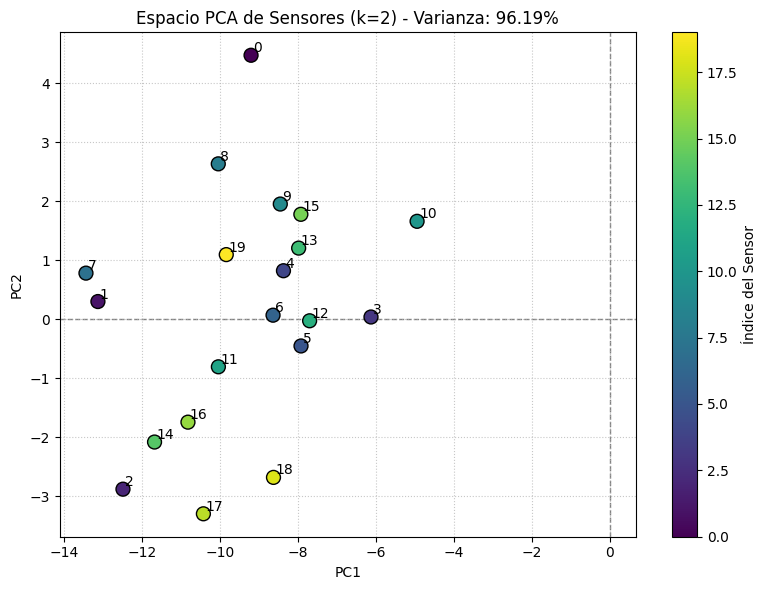

In [20]:
# ==========================================
# P4.2 - PROYECCIÓN EN EL ESPACIO PCA
# ==========================================

# 1. Encontrar k para capturar MÁS del 89% (> 0.89) de la varianza
k = np.argmax(varianza_acumulada > 0.89) + 1

if k < 2:
    k = 2

var_capturada = varianza_acumulada[k-1] * 100

print(f"Número de componentes a usar: k = {k}")
print(f"Varianza acumulada capturada: {var_capturada:.2f}%")

# 2. Calcular los SCORES (Proyección)
V_k = Vt[:k, :].T
scores = X_centrado @ V_k

# 3. Generar la visualización
sensores_idx = np.arange(m)

if k == 2:
    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter plot coloreado por el índice del sensor
    scatter = ax.scatter(scores[:, 0], scores[:, 1], c=sensores_idx,
                         cmap='viridis', s=100, edgecolor='black', zorder=3)

    # Etiquetas de texto para cada punto
    for i in range(m):
        ax.text(scores[i, 0] + 0.05, scores[i, 1] + 0.05, str(i), fontsize=10)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, zorder=1)
    ax.grid(True, linestyle=':', alpha=0.7, zorder=0)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Espacio PCA de Sensores (k={k}) - Varianza: {var_capturada:.2f}%')

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Índice del Sensor')

    plt.tight_layout()
    plt.show()

elif k >= 3:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    pares = [(0, 1, 'PC1', 'PC2'), (0, 2, 'PC1', 'PC3'), (1, 2, 'PC2', 'PC3')]

    for ax, (ix, iy, xlabel, ylabel) in zip(axs, pares):
        scatter = ax.scatter(scores[:, ix], scores[:, iy], c=sensores_idx,
                             cmap='viridis', s=80, edgecolor='black', zorder=3)

        for i in range(m):
            ax.text(scores[i, ix] + 0.05, scores[i, iy] + 0.05, str(i), fontsize=9)

        ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1, zorder=1)
        ax.grid(True, linestyle=':', alpha=0.7, zorder=0)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{xlabel} vs {ylabel}')

    fig.suptitle(f'Espacio PCA de Sensores (k={k}) - Varianza: {var_capturada:.2f}%', fontsize=14, fontweight='bold')

    cbar = fig.colorbar(scatter, ax=axs.ravel().tolist(), fraction=0.015, pad=0.04)
    cbar.set_label('Índice del Sensor')

    plt.tight_layout()
    plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
